# 05 - Evaluación de modelos

En este cuaderno se evalúan los modelos ARIMA, Prophet y LSTM usando las métricas RMSE, MAE y MAPE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
pred_arima = pd.read_csv("../01_data/predicciones_arima.csv")
pred_prophet = pd.read_csv("../01_data/predicciones_prophet.csv")
pred_lstm = pd.read_csv("../01_data/predicciones_lstm.csv")

for df in [pred_arima, pred_prophet, pred_lstm]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)


In [3]:
fechas_iguales = (
    pred_arima["Date"].equals(pred_prophet["Date"])
    and pred_arima["Date"].equals(pred_lstm["Date"])
)

resumen_periodo = pd.DataFrame({
    "Modelo": ["ARIMA", "Prophet", "LSTM"],
    "Fecha inicial": [pred_arima["Date"].min(), pred_prophet["Date"].min(), pred_lstm["Date"].min()],
    "Fecha final": [pred_arima["Date"].max(), pred_prophet["Date"].max(), pred_lstm["Date"].max()],
    "Registros": [len(pred_arima), len(pred_prophet), len(pred_lstm)],
    "Ventas reales en cero": [
        (pred_arima["Real"] == 0).sum(),
        (pred_prophet["Real"] == 0).sum(),
        (pred_lstm["Real"] == 0).sum()
    ]
})

if not fechas_iguales:
    raise ValueError("Los modelos no tienen el mismo periodo de evaluacion.")

resumen_periodo


,Modelo,Fecha inicial,Fecha final,Registros,Ventas reales en cero
0,ARIMA,2015-01-24,2015-07-31,189,0
1,Prophet,2015-01-24,2015-07-31,189,0
2,LSTM,2015-01-24,2015-07-31,189,0


In [4]:
pred_arima.head()

,Date,Real,Prediccion_ARIMA
0,2015-01-24,5811369,"5,775,527.24"
1,2015-01-25,179028,"695,344.67"
2,2015-01-26,9401803,"8,261,890.13"
3,2015-01-27,8392342,"7,913,481.10"
4,2015-01-28,7930037,"7,662,895.67"


In [5]:
pred_prophet.head()

,Date,Real,Prediccion_Prophet
0,2015-01-24,5811369,"6,001,543.23"
1,2015-01-25,179028,"92,172.82"
2,2015-01-26,9401803,"9,413,019.26"
3,2015-01-27,8392342,"8,282,638.15"
4,2015-01-28,7930037,"7,927,264.59"


In [6]:
pred_lstm.head()

,Date,Real,Prediccion_LSTM
0,2015-01-24,"5,811,369.00","5,162,536.63"
1,2015-01-25,"179,028.00","3,429,298.09"
2,2015-01-26,"9,401,803.00","10,624,170.12"
3,2015-01-27,"8,392,342.00","9,352,032.95"
4,2015-01-28,"7,930,037.00","8,672,557.04"


## Cálculo de métricas

In [7]:
def calcular_metricas(real, prediccion):
    real = np.asarray(real, dtype=float)
    prediccion = np.asarray(prediccion, dtype=float)

    rmse = np.sqrt(mean_squared_error(real, prediccion))
    mae = mean_absolute_error(real, prediccion)

    # El MAPE no debe dividir entre cero. Si existieran ventas reales en cero,
    # se excluyen solo para esta metrica.
    mascara_mape = real != 0
    if mascara_mape.sum() == 0:
        mape = np.nan
    else:
        mape = np.mean(
            np.abs((real[mascara_mape] - prediccion[mascara_mape]) / real[mascara_mape])
        ) * 100

    return rmse, mae, mape


In [8]:
rmse_arima, mae_arima, mape_arima = calcular_metricas(
    pred_arima["Real"],
    pred_arima["Prediccion_ARIMA"]
)

rmse_prophet, mae_prophet, mape_prophet = calcular_metricas(
    pred_prophet["Real"],
    pred_prophet["Prediccion_Prophet"]
)

rmse_lstm, mae_lstm, mape_lstm = calcular_metricas(
    pred_lstm["Real"],
    pred_lstm["Prediccion_LSTM"]
)

In [ ]:
metricas = pd.DataFrame({
    "Modelo": ["ARIMA", "Prophet", "LSTM"],
    "RMSE": [rmse_arima, rmse_prophet, rmse_lstm],
    "MAE": [mae_arima, mae_prophet, mae_lstm],
    "MAPE (%)": [mape_arima, mape_prophet, mape_lstm]
})

metricas

,Modelo,RMSE,MAE,MAPE (%)
0,ARIMA,"2,045,074.55","1,272,695.19",140.21
1,Prophet,"968,447.14","685,105.41",24.31
2,LSTM,"1,710,638.53","1,219,261.28",151.25


In [10]:
mejor_modelo_rmse = metricas.sort_values("RMSE").iloc[0]["Modelo"]
mejor_modelo_mae = metricas.sort_values("MAE").iloc[0]["Modelo"]
mejor_modelo_mape = metricas.sort_values("MAPE (%)").iloc[0]["Modelo"]

resumen_mejores = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "MAPE"],
    "Mejor modelo": [mejor_modelo_rmse, mejor_modelo_mae, mejor_modelo_mape]
})

resumen_mejores

,Métrica,Mejor modelo
0,RMSE,Prophet
1,MAE,Prophet
2,MAPE,Prophet


## Comparación gráfica de métricas

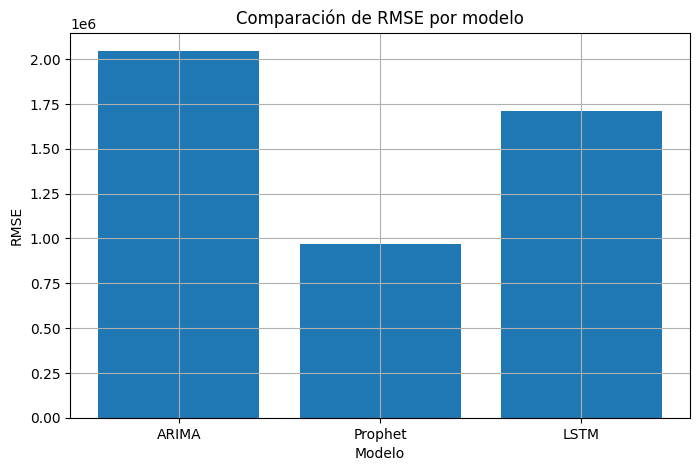

In [11]:
plt.figure(figsize=(8,5))
plt.bar(metricas["Modelo"], metricas["RMSE"])
plt.title("Comparación de RMSE por modelo")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

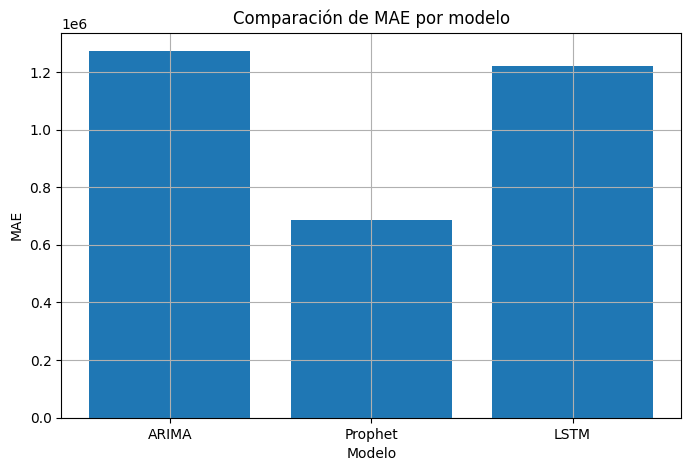

In [12]:
plt.figure(figsize=(8,5))
plt.bar(metricas["Modelo"], metricas["MAE"])
plt.title("Comparación de MAE por modelo")
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.grid(True)
plt.show()

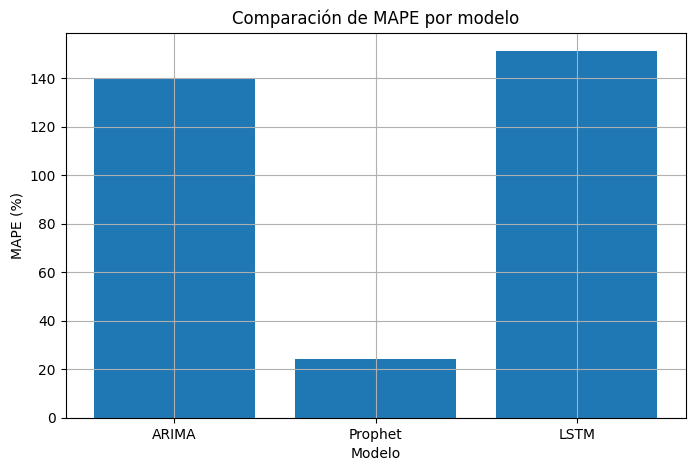

In [13]:
plt.figure(figsize=(8,5))
plt.bar(metricas["Modelo"], metricas["MAPE (%)"])
plt.title("Comparación de MAPE por modelo")
plt.xlabel("Modelo")
plt.ylabel("MAPE (%)")
plt.grid(True)
plt.show()

## Comparación de predicciones

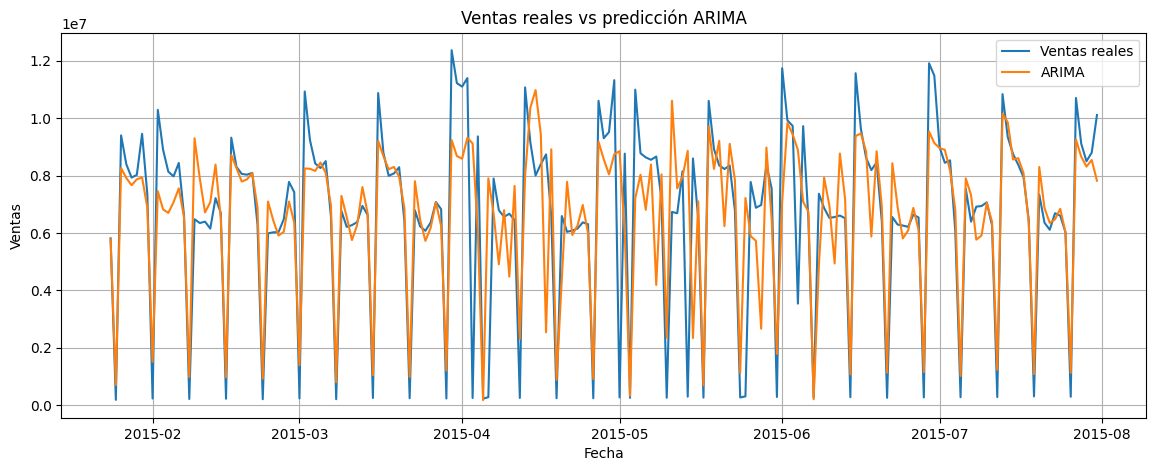

In [14]:
plt.figure(figsize=(14,5))
plt.plot(pred_arima["Date"], pred_arima["Real"], label="Ventas reales")
plt.plot(pred_arima["Date"], pred_arima["Prediccion_ARIMA"], label="ARIMA")
plt.title("Ventas reales vs predicción ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

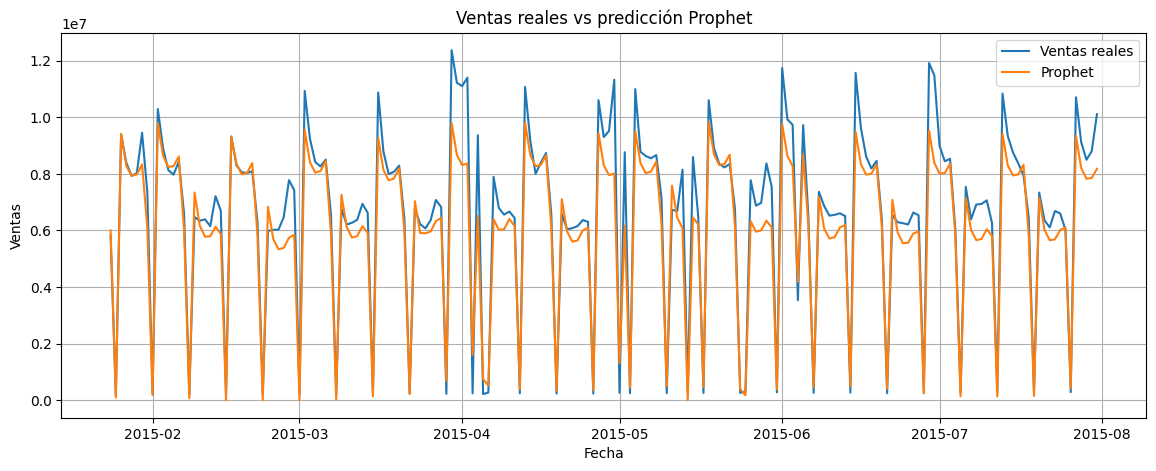

In [15]:
plt.figure(figsize=(14,5))
plt.plot(pred_prophet["Date"], pred_prophet["Real"], label="Ventas reales")
plt.plot(pred_prophet["Date"], pred_prophet["Prediccion_Prophet"], label="Prophet")
plt.title("Ventas reales vs predicción Prophet")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

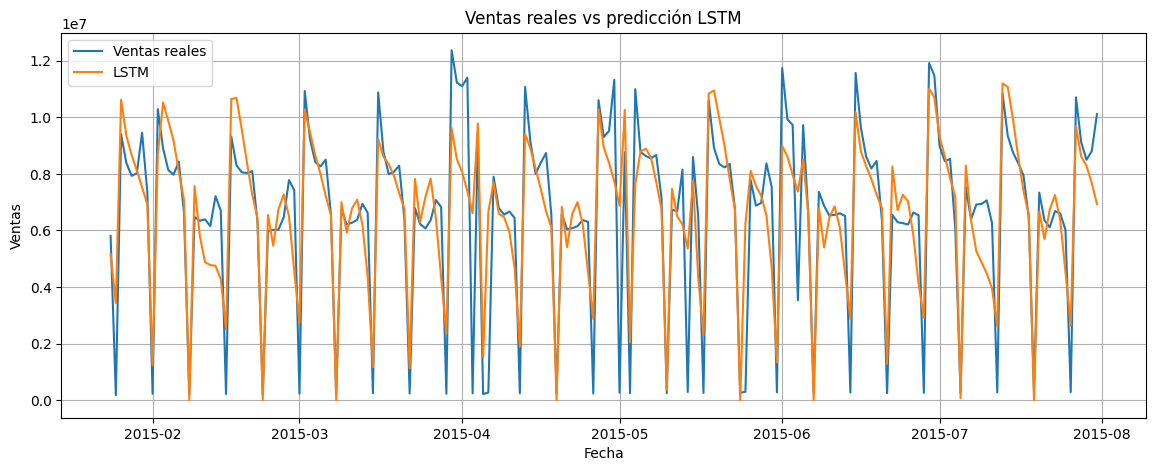

In [16]:
plt.figure(figsize=(14,5))
plt.plot(pred_lstm["Date"], pred_lstm["Real"], label="Ventas reales")
plt.plot(pred_lstm["Date"], pred_lstm["Prediccion_LSTM"], label="LSTM")
plt.title("Ventas reales vs predicción LSTM")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
metricas.to_csv("../01_data/metricas_modelos.csv", index=False)

## Conclusion

Se evaluaron los modelos ARIMA, Prophet y LSTM mediante las metricas RMSE, MAE y MAPE.

De acuerdo con los resultados obtenidos, Prophet presento el mejor desempeno general, ya que obtuvo los menores valores de error en las tres metricas evaluadas. El modelo alcanzo un RMSE de 968,447.14, un MAE de 685,105.41 y un MAPE de 24.31%.

ARIMA se utilizo como modelo base de serie temporal. Prophet incorporo variables externas mediante un enfoque especializado en series temporales. LSTM incorporo variables externas del dataset y se mantiene como modelo comparativo.

Por lo tanto, Prophet se selecciona como modelo principal para el dashboard de prediccion y para la simulacion de escenarios. ARIMA y LSTM se mantienen como comparativos para evidenciar el cumplimiento de los tres modelos solicitados en el taller.
